# Stock & Company Financial Health Tracker
### Data Analytics Project — 30 IT-Industry Companies

This notebook documents the full analysis pipeline: data collection, cleaning,
SQL-based exploration, financial ratio analysis, and sector-leader identification
for 30 publicly listed IT-industry companies across six sub-sectors (Software,
Semiconductors, Hardware, Internet & Cloud, IT Services, Cybersecurity).

**Pipeline:** `data/raw/build_raw_dataset.py` → `src/load_to_sqlite.py` (SQLite) →
`src/clean_data.py` (pandas cleaning) → SQL analysis (`sql/analysis_queries.sql`) →
`src/ratio_analysis.py` (ratios + charts) → `dashboard/app.py` (Streamlit).

Data source: [stockanalysis.com](https://stockanalysis.com) company financial
statements and ratio pages, accessed 2026-09-08. Figures are as originally
reported by each company (SAP figures in EUR millions; all others USD millions).

## 1. Load the cleaned dataset

The raw data (150 company-year rows) was collected from 30 companies, loaded into a SQLite database, then cleaned in `src/clean_data.py` — duplicate rows dropped, TTM rows removed for clean year-over-year comparison, net profit margin recomputed directly from net income / revenue, and structurally negative-equity companies (Dell, HP Inc.) flagged rather than silently distorting sector averages.

In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/processed/financials.db")
df = pd.read_sql_query("SELECT * FROM financials_clean", conn, parse_dates=["period_ending"])
companies = pd.read_sql_query("SELECT * FROM companies", conn)

print(f"{df['ticker'].nunique()} companies, {len(df)} company-year rows, {df['sector'].nunique()} sectors")
df.head()

30 companies, 132 company-year rows, 6 sectors


## 2. Missing data

A handful of ratios are `NULL` by design rather than filled with 0 — P/E and ROE are not economically meaningful for a company with negative or near-zero earnings in a given year (e.g. CrowdStrike, Intel in loss-making years), and filling them with 0 would badly distort sector averages.

In [2]:
df[["pe_ratio", "debt_to_equity", "roe_pct"]].isna().sum()

pe_ratio          13
debt_to_equity    10
roe_pct           12


## 3. SQL analysis — business questions

Queries live in `sql/analysis_queries.sql`. Below: which sector has the best average net profit margin, and which companies grew revenue every single year in the dataset (both via SQL against the SQLite database, not pandas).

In [3]:
query = """
WITH latest AS (
    SELECT f.*, ROW_NUMBER() OVER (PARTITION BY ticker ORDER BY period_ending DESC) rn
    FROM financials_clean f
)
SELECT sector, ROUND(AVG(net_profit_margin_pct), 2) AS avg_net_margin_pct, COUNT(*) AS n_companies
FROM latest WHERE rn = 1 GROUP BY sector ORDER BY avg_net_margin_pct DESC;
"""
pd.read_sql_query(query, conn)

          sector  avg_net_margin_pct  n_companies
Internet & Cloud               31.45            2
  Semiconductors               23.90            7
        Software               21.83            8
        Hardware               11.50            5
     IT Services               10.77            5
   Cybersecurity                8.85            3


## 4. Financial ratios & sector leaders

Full ratio calculations (Revenue Growth, Net Profit Margin, Debt-to-Equity, ROE, EPS, P/E) live in `src/ratio_analysis.py`. Top 3 healthiest companies per sector, by a composite health score (ROE + net margin − debt/equity×10, most recent fiscal year):

In [4]:
%run ../src/ratio_analysis.py

Top 3 healthiest companies per sector:
           sector  sector_rank ticker                          company_name  health_score  roe_pct  net_profit_margin_pct  debt_to_equity
   Cybersecurity            1   FTNT                         Fortinet Inc.        154.37   135.72                  27.25            0.86
   Cybersecurity            2   PANW               Palo Alto Networks Inc.          3.51     1.74                   2.67            0.09
   Cybersecurity            3   CRWD             CrowdStrike Holdings Inc.         -9.32    -4.14                  -3.38            0.18
        Hardware            1   AAPL                            Apple Inc.        183.14   171.42                  26.92            1.52
        Hardware            2   CSCO                    Cisco Systems Inc.         42.07    27.32                  20.95            0.62
        Hardware            3   DELL                Dell Technologies Inc.          5.23      NaN                   5.23             NaN
 

## 5. Charts

### Revenue trend — largest company per sector

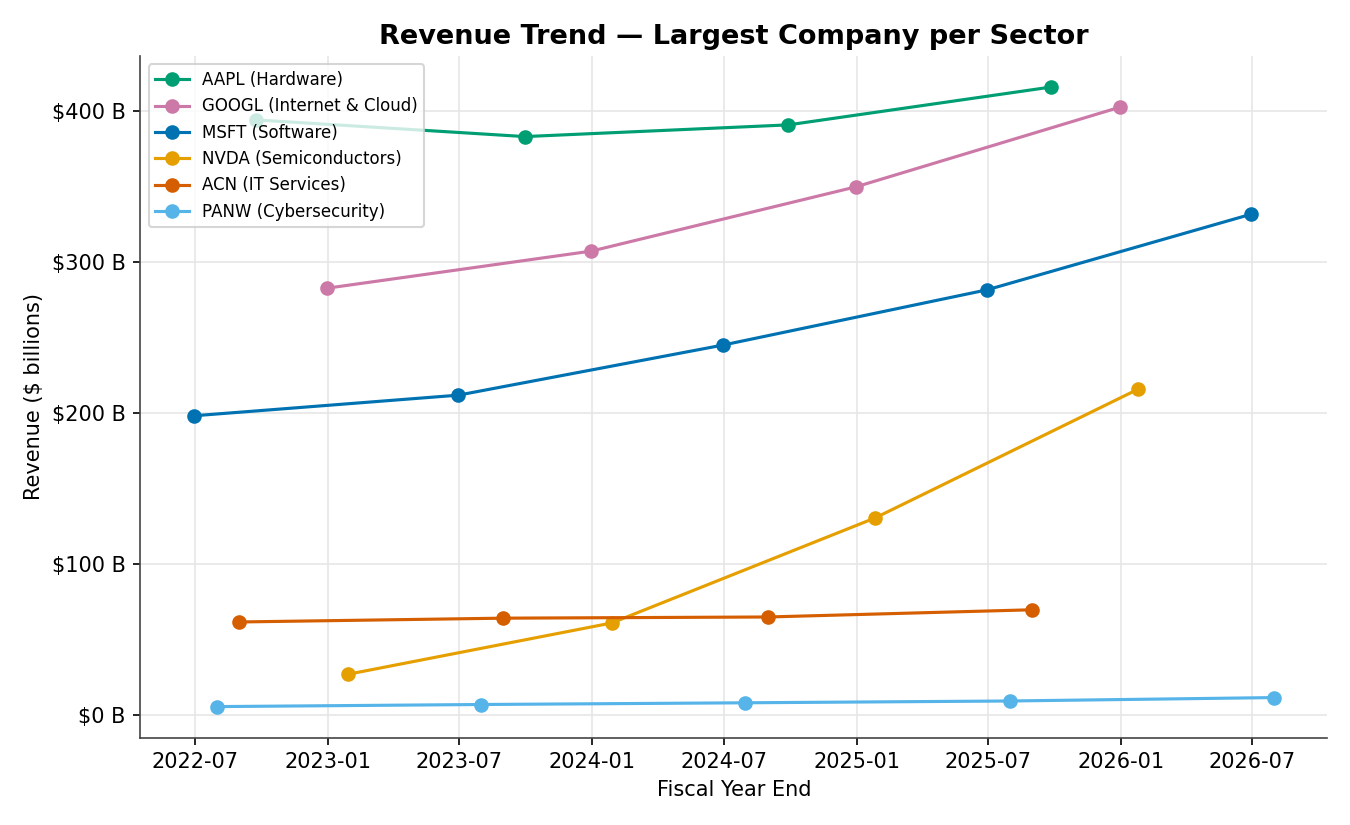

In [5]:
from IPython.display import Image
Image("../charts/revenue_trend.png")

### Net profit margin by sector

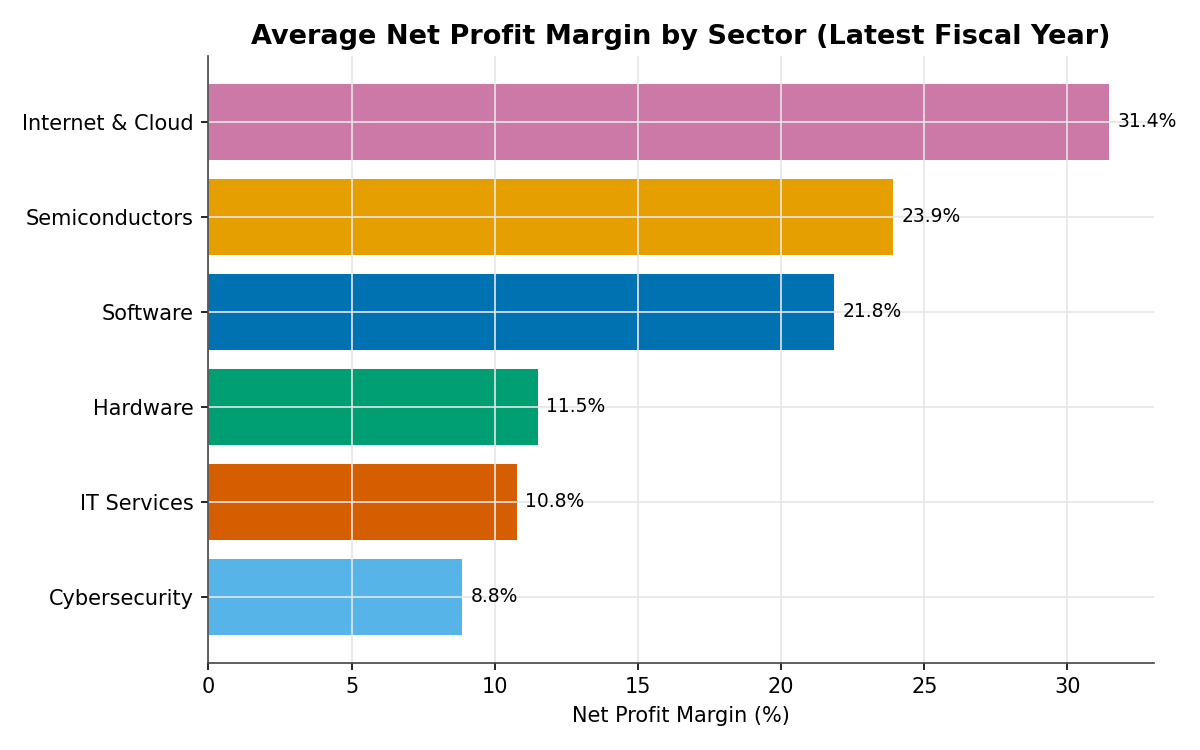

In [6]:
Image("../charts/margin_comparison.png")

### Return on equity vs. debt-to-equity

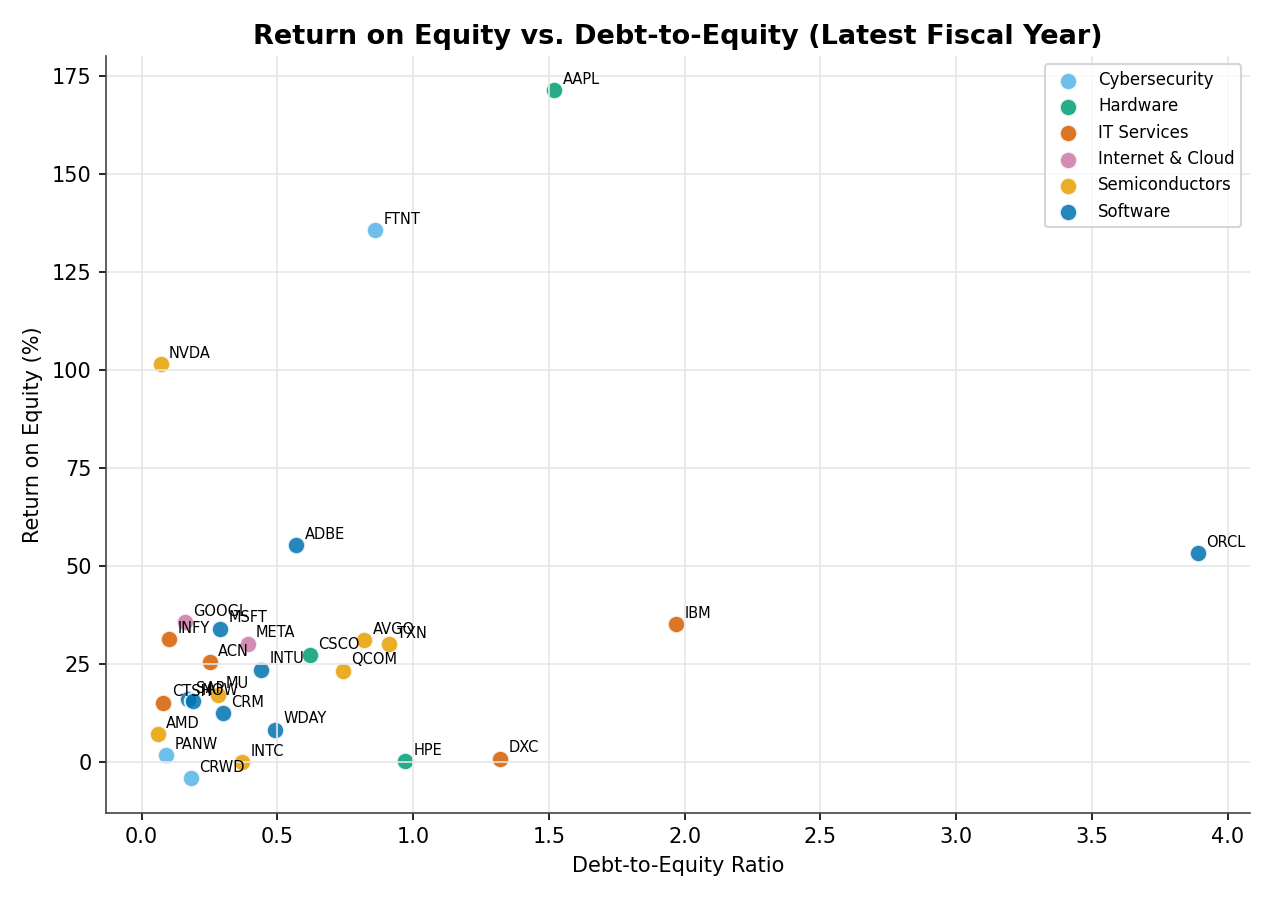

In [7]:
Image("../charts/roe_vs_de_scatter.png")

### Largest year-over-year EPS swings

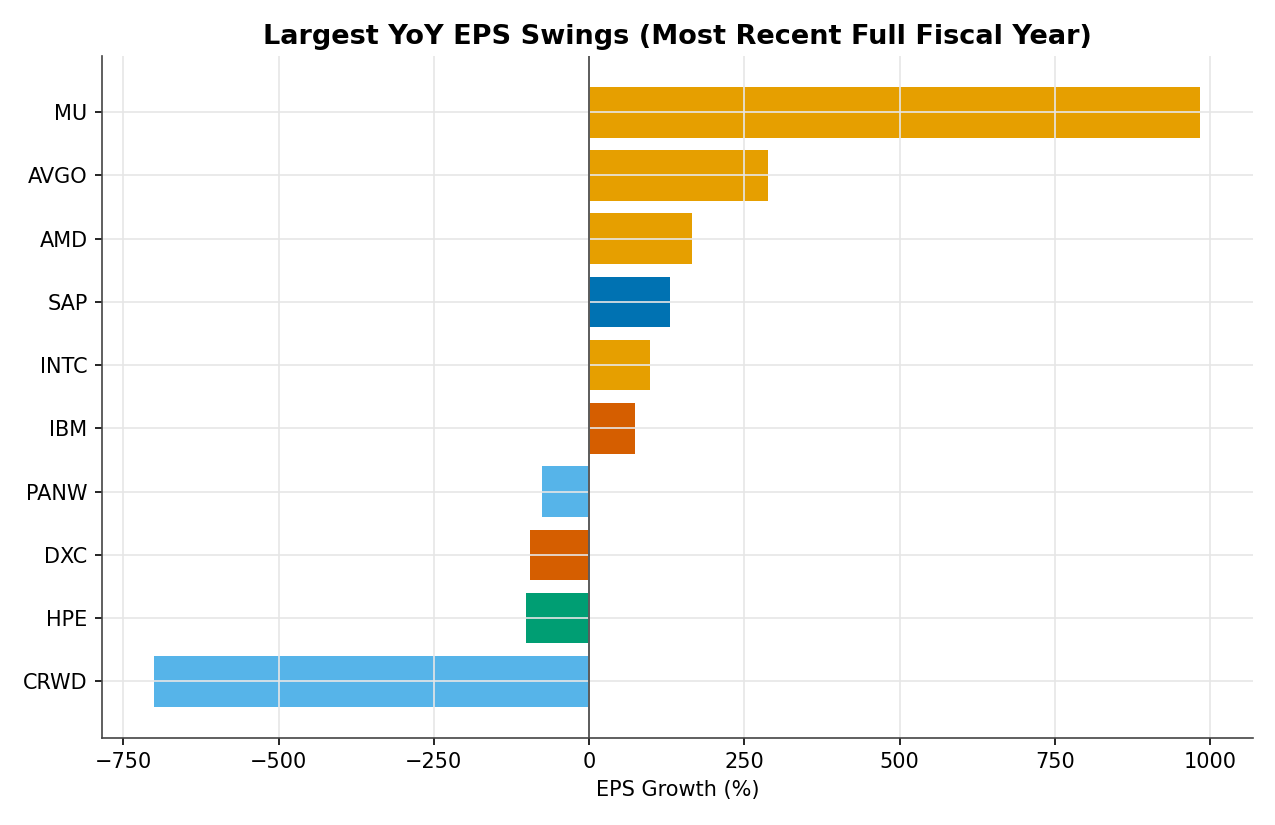

In [8]:
Image("../charts/eps_growth_leaders.png")

## 6. Key findings

- **Internet & Cloud and Semiconductors post the highest net margins** — Alphabet and Meta both clear 30% net margin, and AI-driven demand pushed NVIDIA's margin above 55% in its latest fiscal year, far ahead of every other company in the dataset.
- **Software carries the most financial risk on paper, but it's mostly an artifact of buybacks, not distress** — Oracle's debt-to-equity ratio (3.89x) looks alarming next to typical software peers (Microsoft 0.29x, ServiceNow 0.19x), but it stems from aggressive share buybacks shrinking the equity base rather than excessive borrowing.
- **Cybersecurity is the growth-over-profitability sector** — CrowdStrike, Palo Alto Networks and Fortinet all show strong, consistent double-digit revenue growth, but only Fortinet has settled into consistent GAAP profitability; the other two show volatile or negative net income in several years.
- **Apple stands alone on capital efficiency** — a 148–175% ROE range across the last five fiscal years, driven by a historically small equity base relative to its profit, is unmatched by any other hardware company in the set.
- **IT services (Accenture, Cognizant, Infosys) are the steadiest, least volatile performers** — mid-single-to-low-double-digit revenue growth, low debt, and ROE in the 15–32% range every year, with none of the swings seen in semiconductors or cybersecurity.

## 7. Future improvements

- Add ML-based revenue forecasting (e.g. simple linear trend or Prophet) per company.
- Expand from 30 to the full IT-industry universe using a paid data API for automated refresh.
- Add quarterly (not just annual) granularity for more responsive trend detection.
- Layer in stock price history to compute realised total shareholder return, not just accounting ratios.